In [1]:
import pandas as pd 
import numpy as numpy 
import joblib 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("Training.csv")
df

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,(vertigo) Paroymsal Positional Vertigo
4916,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,Acne
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Urinary tract infection
4918,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,0,0,0,Psoriasis


In [3]:
df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


In [5]:
df.isnull().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

In [6]:
df['prognosis'] = df['prognosis'].str.strip()
df['prognosis'] = df['prognosis'].str.replace(r'\s+', ' ', regex=True)
print(df['prognosis'].unique().tolist())

['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis', 'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes', 'Gastroenteritis', 'Bronchial Asthma', 'Hypertension', 'Migraine', 'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice', 'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia', 'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins', 'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia', 'Osteoarthristis', 'Arthritis', '(vertigo) Paroymsal Positional Vertigo', 'Acne', 'Urinary tract infection', 'Psoriasis', 'Impetigo']


In [7]:
df['prognosis'] = df['prognosis'].replace('Peptic ulcer diseae', 'Peptic ulcer disease')

In [8]:
X = df.drop('prognosis' , axis=1)
Y = df['prognosis']

In [9]:
symptom_list = list(X.columns)
joblib.dump(symptom_list , 'symptom_columns.pkl')


['symptom_columns.pkl']

In [10]:
le = LabelEncoder()
y_enc = le.fit_transform(Y)

In [11]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2 , random_state=42 , stratify=y_enc)


In [12]:
X_train.shape

(3936, 132)

In [13]:
X_test.shape

(984, 132)

### DECISION TREE 

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.model_selection import cross_val_score 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [15]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train , Y_train)

DecisionTreeClassifier(random_state=42)

In [16]:
y_pred_dt = dt.predict(X_test)

In [17]:
acc_dt = accuracy_score(Y_test , y_pred_dt)
acc_dt

1.0

In [18]:
cv_dt = cross_val_score(dt , X_train , Y_train , cv=5 , scoring="accuracy")
cv_dt.mean()

np.float64(0.9994917407878019)

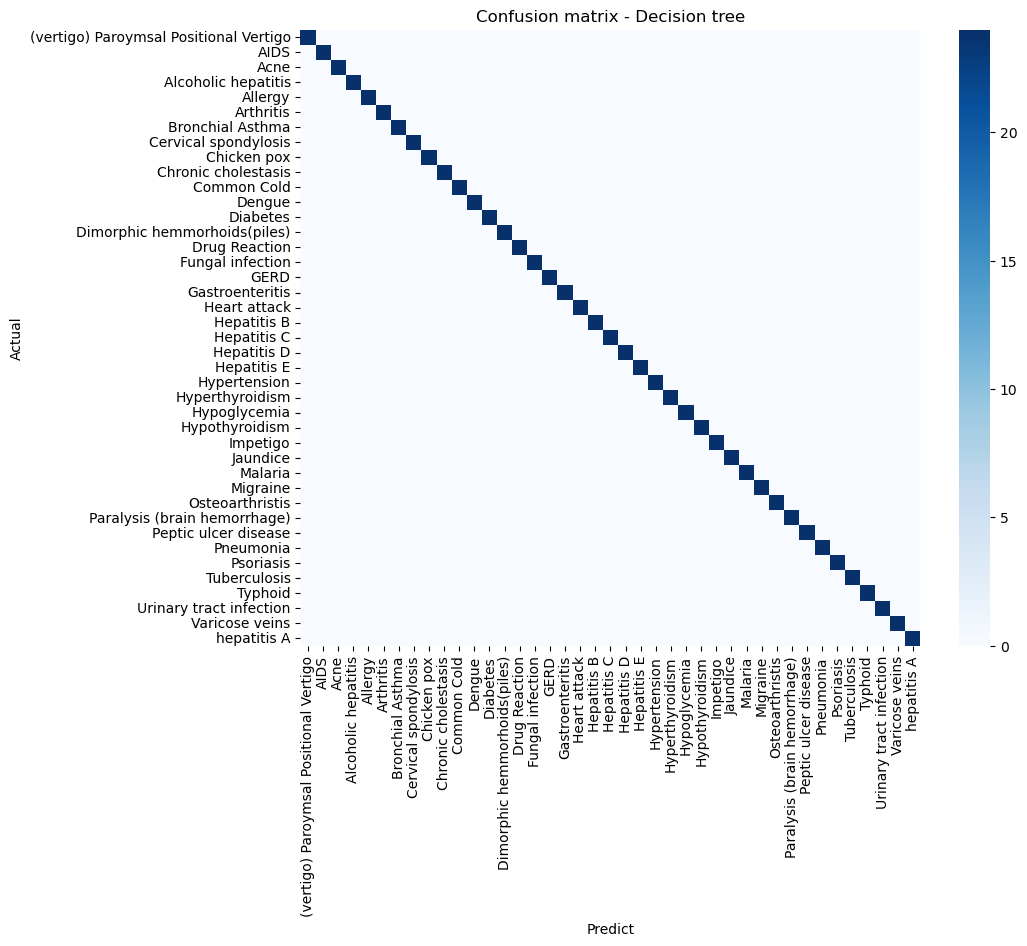

In [19]:
cm_dt = confusion_matrix(Y_test , y_pred_dt)
plt.figure(figsize = (10,8))
sns.heatmap(cm_dt , annot=False , cmap = 'Blues',xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion matrix - Decision tree")
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.show()

In [20]:
classification_report(Y_test , y_pred_dt , target_names= le.classes_)

'                                        precision    recall  f1-score   support\n\n(vertigo) Paroymsal Positional Vertigo       1.00      1.00      1.00        24\n                                  AIDS       1.00      1.00      1.00        24\n                                  Acne       1.00      1.00      1.00        24\n                   Alcoholic hepatitis       1.00      1.00      1.00        24\n                               Allergy       1.00      1.00      1.00        24\n                             Arthritis       1.00      1.00      1.00        24\n                      Bronchial Asthma       1.00      1.00      1.00        24\n                  Cervical spondylosis       1.00      1.00      1.00        24\n                           Chicken pox       1.00      1.00      1.00        24\n                   Chronic cholestasis       1.00      1.00      1.00        24\n                           Common Cold       1.00      1.00      1.00        24\n                         

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(Y_test, y_pred_rf)
acc_rf

1.0

In [23]:
cv_rf = cross_val_score(rf, X_train, Y_train, cv=5)
print(f"Random Forest CV Mean: {cv_rf.mean():.4f}")

Random Forest CV Mean: 1.0000


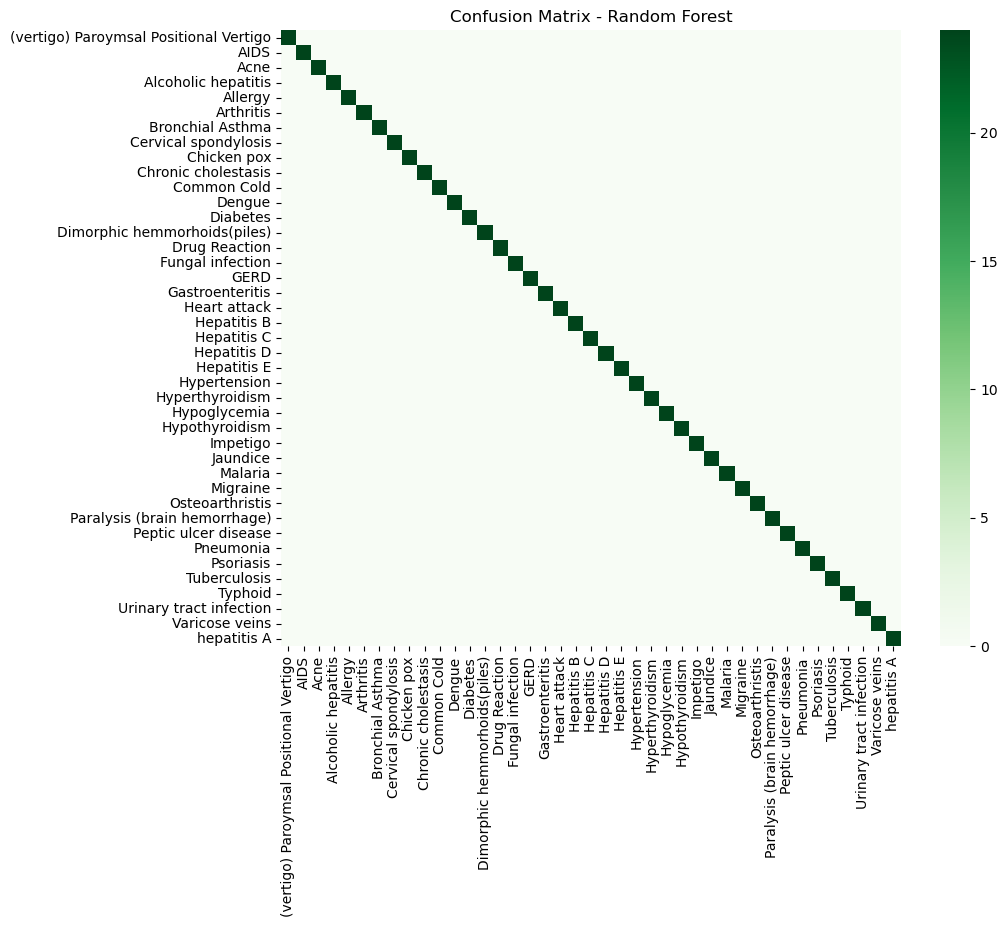

In [24]:
cm_rf = confusion_matrix(Y_test, y_pred_rf)
plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=False, cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, Y_train)

GradientBoostingClassifier(random_state=42)

In [26]:
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(Y_test, y_pred_gb)
acc_gb

1.0

In [27]:
cv_gb = cross_val_score(rf, X_train, Y_train, cv=5)
cv_gb.mean()

np.float64(1.0)

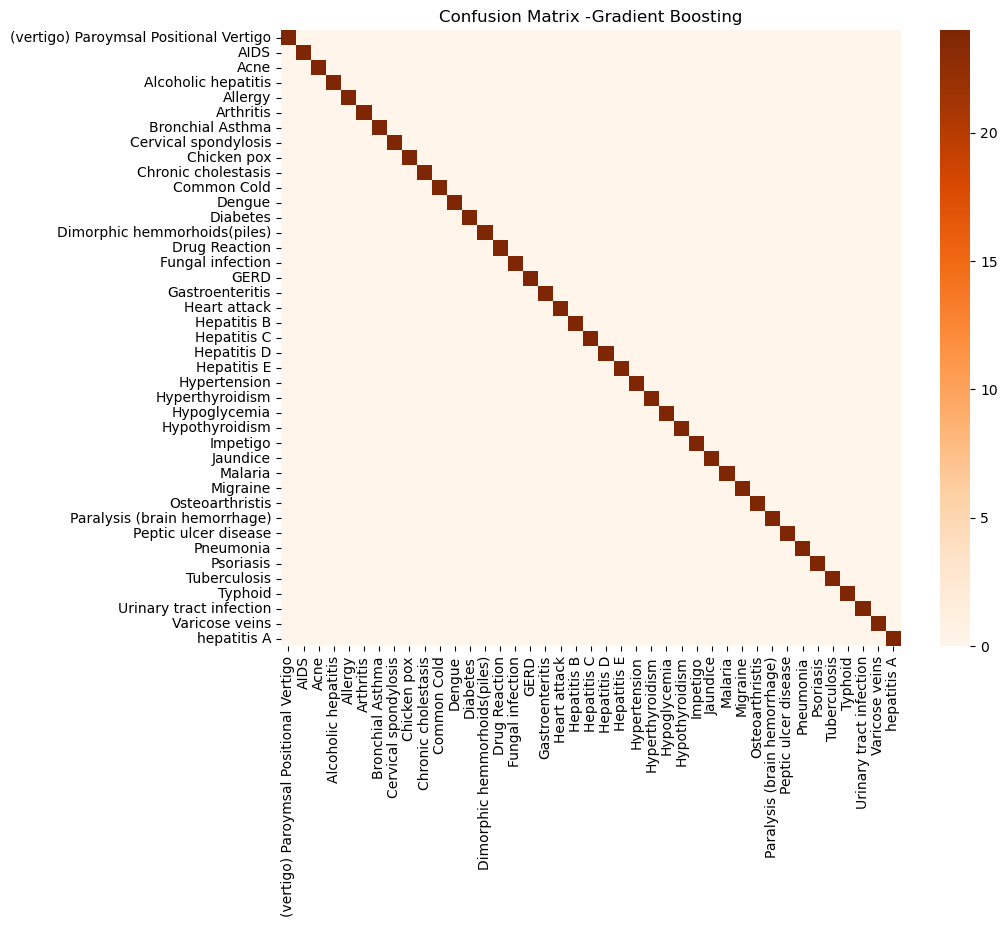

In [28]:
cm_gb = confusion_matrix(Y_test, y_pred_rf)
plt.figure(figsize=(10,8))
sns.heatmap(cm_gb, annot=False, cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix -Gradient Boosting')
plt.show()

In [29]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, Y_train)

SVC(probability=True, random_state=42)

In [30]:
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(Y_test, y_pred_svm)
acc_svm

1.0

In [31]:
cv_svm = cross_val_score(svm, X_train, Y_train, cv=5)
cv_svm.mean()

np.float64(1.0)

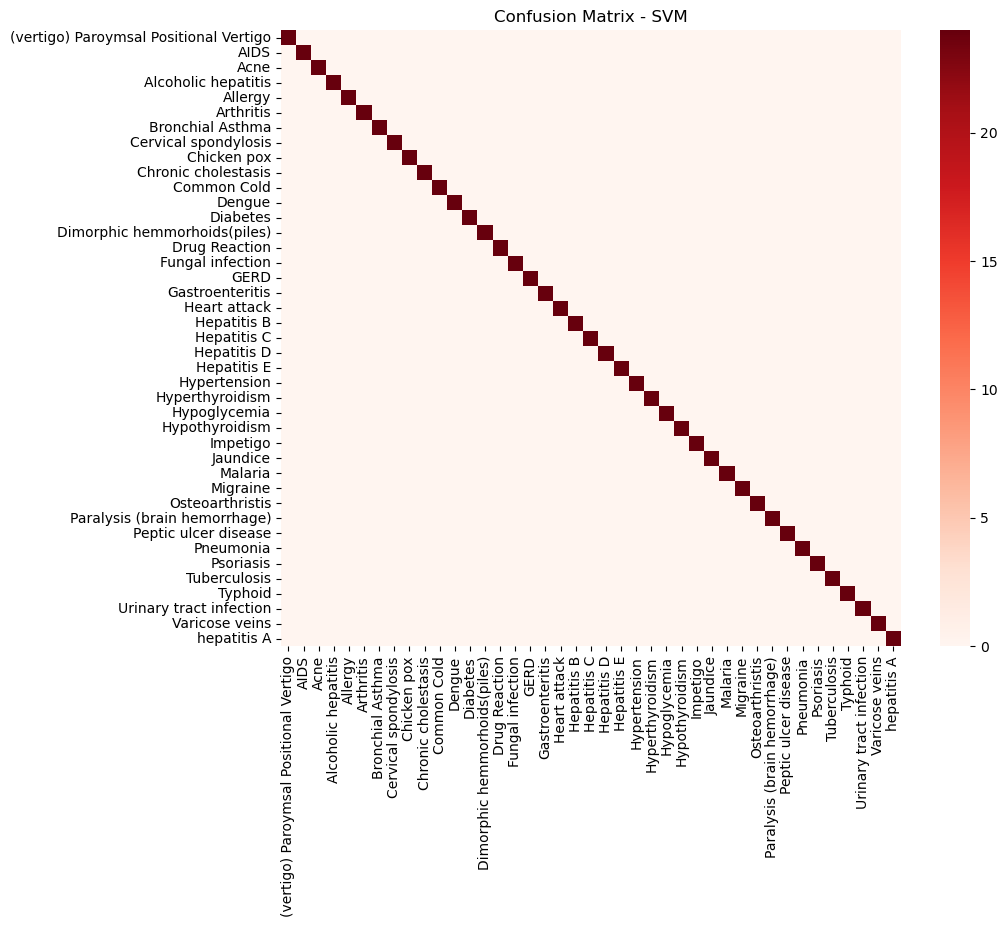

In [32]:
cm_svm = confusion_matrix(Y_test, y_pred_svm)
plt.figure(figsize=(10,8))
sns.heatmap(cm_svm, annot=False, cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - SVM')
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(Y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")


Logistic Regression Accuracy: 1.0000


In [35]:
cv_lr = cross_val_score(lr, X_train, Y_train, cv=5)
print(f"Logistic Regression CV Mean: {cv_lr.mean():.4f}")


Logistic Regression CV Mean: 1.0000


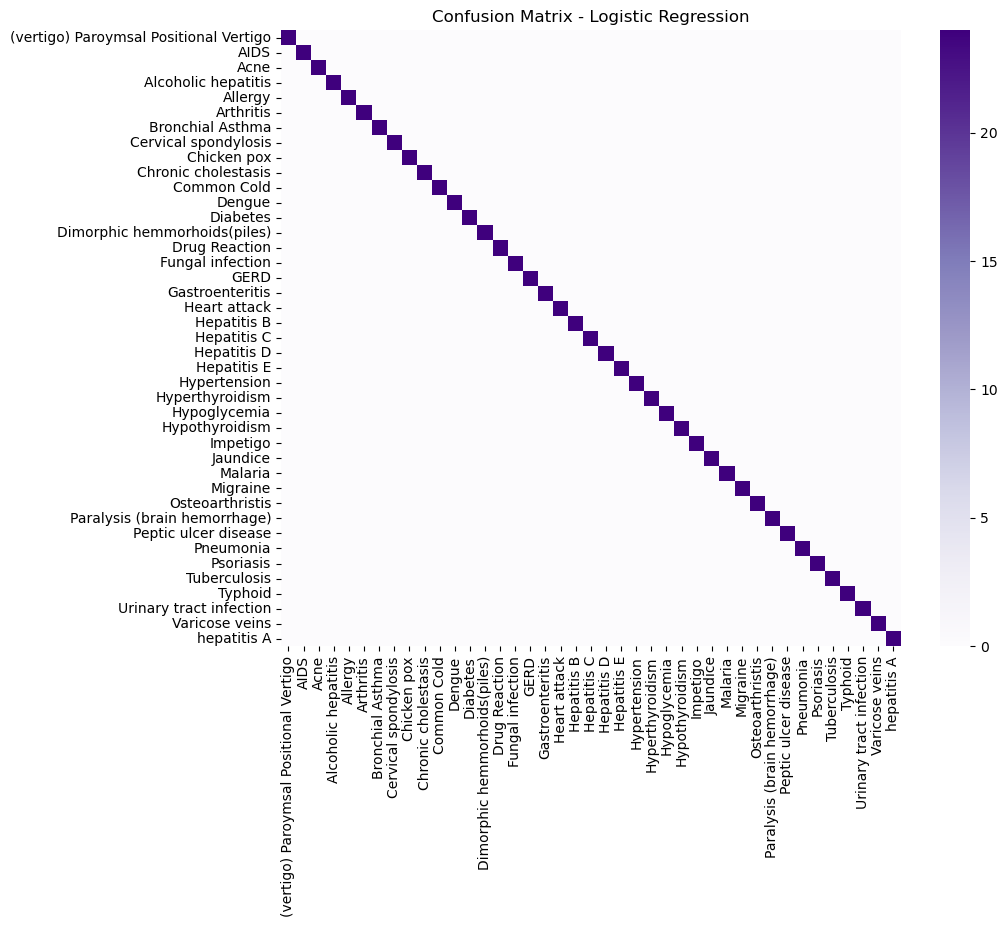

In [36]:
cm_lr = confusion_matrix(Y_test, y_pred_lr)
plt.figure(figsize=(10,8))
sns.heatmap(cm_lr, annot=False, cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

KNeighborsClassifier()

In [38]:
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(Y_test, y_pred_knn)
acc_knn

1.0

In [39]:
cv_knn = cross_val_score(knn, X_train, Y_train, cv=5)
cv_knn.mean()


np.float64(1.0)

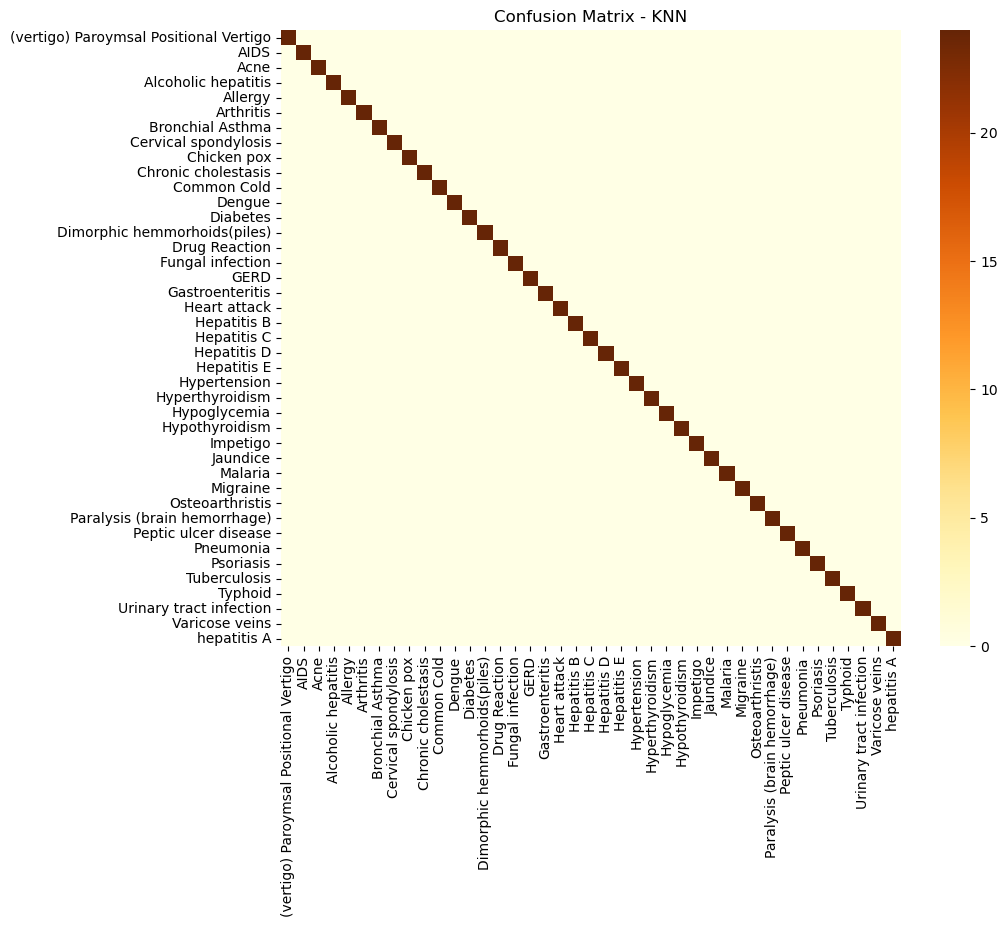

In [40]:
cm_knn = confusion_matrix(Y_test, y_pred_knn)
plt.figure(figsize=(10,8))
sns.heatmap(cm_knn, annot=False, cmap='YlOrBr', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - KNN')
plt.show()

In [41]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, Y_train)

GaussianNB()

In [42]:
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(Y_test, y_pred_nb)
acc_nb

1.0

In [43]:
cv_nb = cross_val_score(nb, X_train, Y_train, cv=5)
cv_nb.mean()

np.float64(1.0)

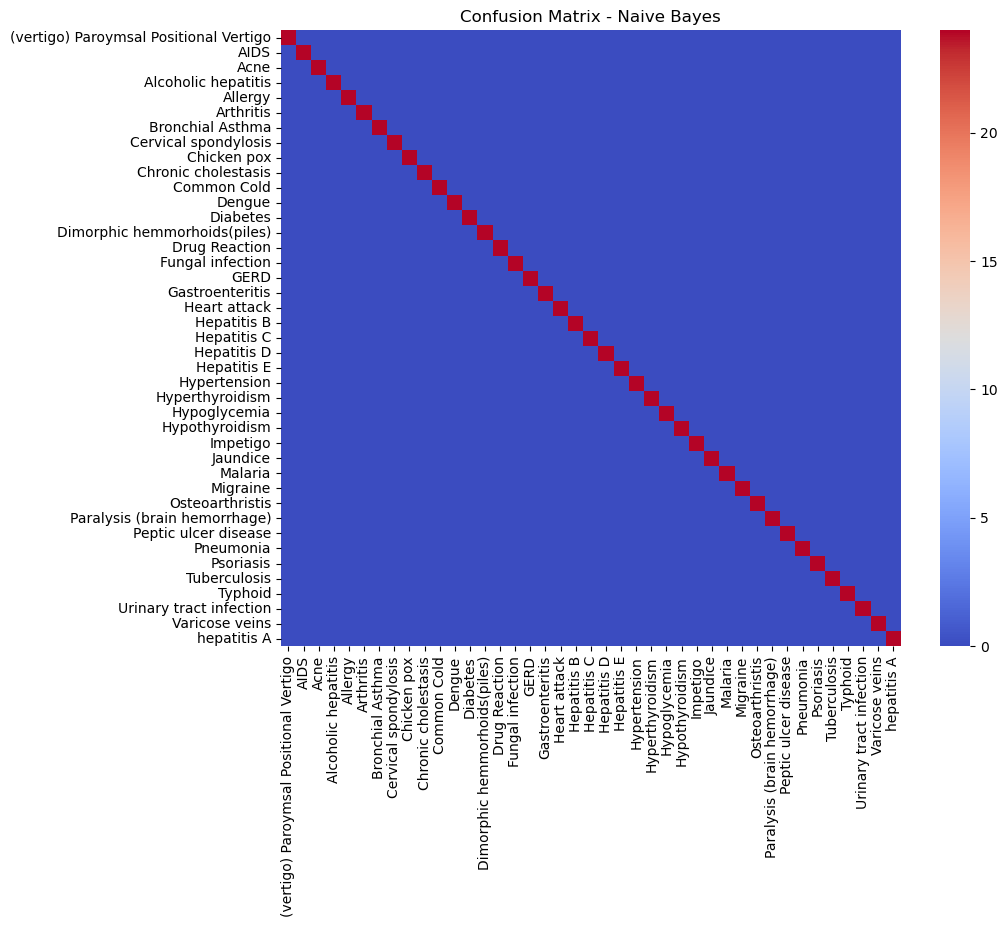

In [44]:
cm_nb = confusion_matrix(Y_test, y_pred_nb)
plt.figure(figsize=(10,8))
sns.heatmap(cm_nb, annot=False, cmap='coolwarm', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

In [45]:
results = {
    'Decision Tree': acc_dt,
    'Random Forest': acc_rf,
    'Gradient Boosting': acc_gb,
    'SVM': acc_svm,
    'Logistic Regression': acc_lr,
    'KNN': acc_knn,
    'Naive Bayes': acc_nb
}

import pandas as pd
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Test Accuracy'])
results_df['CV Mean'] = [cv_dt.mean(), cv_rf.mean(), cv_gb.mean(), cv_svm.mean(), 
                         cv_lr.mean(), cv_knn.mean(), cv_nb.mean()]
print(results_df.sort_values(by='Test Accuracy', ascending=False))

                 Model  Test Accuracy   CV Mean
0        Decision Tree            1.0  0.999492
1        Random Forest            1.0  1.000000
2    Gradient Boosting            1.0  1.000000
3                  SVM            1.0  1.000000
4  Logistic Regression            1.0  1.000000
5                  KNN            1.0  1.000000
6          Naive Bayes            1.0  1.000000


C:\Users\shiva\AppData\Local\Temp\ipykernel_15532\1178527448.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Model', y='Test Accuracy', data=results_df, palette='viridis')


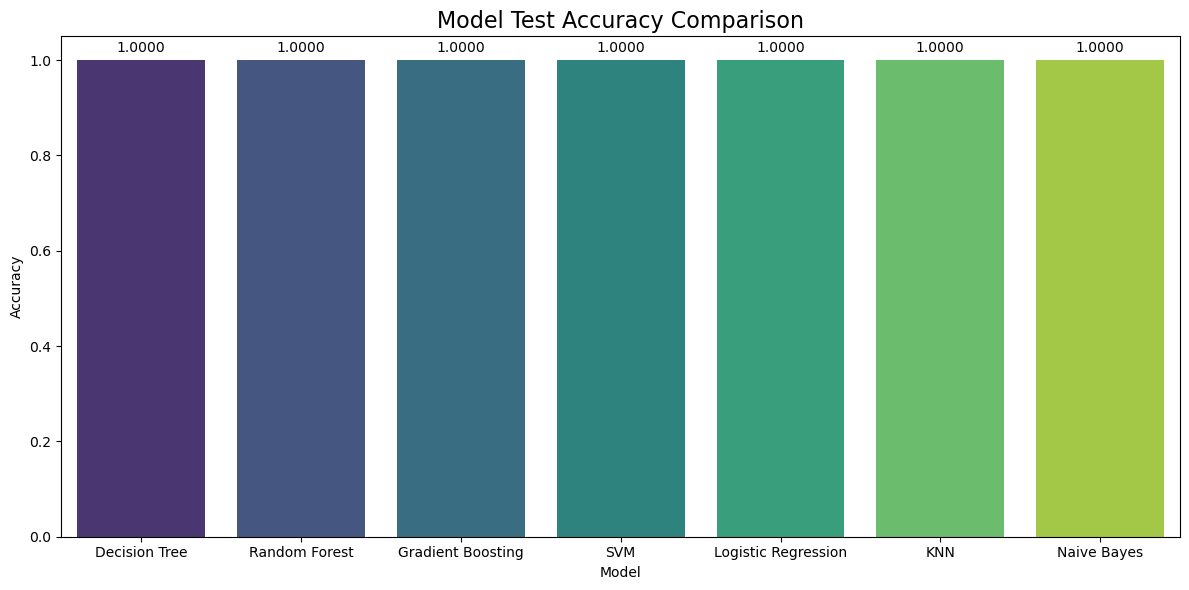

Final Accuracy Ranking:
              Model  Test Accuracy
      Decision Tree            1.0
      Random Forest            1.0
  Gradient Boosting            1.0
                SVM            1.0
Logistic Regression            1.0
                KNN            1.0
        Naive Bayes            1.0


In [46]:
results = {
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting', 
              'SVM', 'Logistic Regression', 'KNN', 'Naive Bayes'],
    'Test Accuracy': [acc_dt, acc_rf, acc_gb, acc_svm, acc_lr, acc_knn, acc_nb]
}
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test Accuracy', ascending=False)


plt.figure(figsize=(12,6))
barplot = sns.barplot(x='Model', y='Test Accuracy', data=results_df, palette='viridis')
plt.ylim(0, 1.05)
plt.title('Model Test Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Model')

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.4f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 9), textcoords='offset points')
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150)
plt.show()


print("Final Accuracy Ranking:")
print(results_df.to_string(index=False))

In [47]:
joblib.dump(rf, 'best_model.pkl')
joblib.dump(le, 'label_encoder.pkl') 

['label_encoder.pkl']

#### This dataset has clean, non-overlapping symptom patterns per disease, hence all models achieve near-perfect accuracy. In real-world clinical data, overlapping symptoms would reduce this. Random Forest was chosen as the final model for its robustness and feature importance interpretability.

In [48]:
print(df['prognosis'].unique().tolist())

['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis', 'Drug Reaction', 'Peptic ulcer disease', 'AIDS', 'Diabetes', 'Gastroenteritis', 'Bronchial Asthma', 'Hypertension', 'Migraine', 'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice', 'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia', 'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins', 'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia', 'Osteoarthristis', 'Arthritis', '(vertigo) Paroymsal Positional Vertigo', 'Acne', 'Urinary tract infection', 'Psoriasis', 'Impetigo']


## Precaution

In [49]:
df_precaution = pd.read_csv("Disease precaution.csv")

In [50]:
df_precaution['Disease'] = df_precaution['Disease'].str.strip()

In [51]:
df_precaution.head(5)

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [52]:
training_diseases = set(df['prognosis'].unique())
precaution_diseases = set(df_precaution['Disease'].unique())
missing_in_precaution = training_diseases - precaution_diseases
print("Missing:", missing_in_precaution)

Missing: {'Peptic ulcer disease', '(vertigo) Paroymsal Positional Vertigo'}


In [53]:
# Exact characters check karo (repr use karke hidden spaces dikh jayenge)
train_list = [d for d in df['prognosis'].unique() if 'Peptic' in d]
prec_list = [d for d in df_precaution['Disease'].unique() if 'Peptic' in d]
print("Training:", [repr(x) for x in train_list])
print("Precaution:", [repr(x) for x in prec_list])

Training: ["'Peptic ulcer disease'"]
Precaution: ["'Peptic ulcer diseae'"]


In [54]:
train_list2 = [d for d in df['prognosis'].unique() if 'vertigo' in d.lower()]
prec_list2 = [d for d in df_precaution['Disease'].unique() if 'vertigo' in d.lower()]
print("Training:", [repr(x) for x in train_list2])
print("Precaution:", [repr(x) for x in prec_list2])

Training: ["'(vertigo) Paroymsal Positional Vertigo'"]
Precaution: ["'(vertigo) Paroymsal  Positional Vertigo'"]


In [55]:
df_precaution['Disease'] = df_precaution['Disease'].replace('Peptic ulcer diseae', 'Peptic ulcer disease')
df_precaution['Disease'] = df_precaution['Disease'].str.replace(r'\s+', ' ', regex=True)  # multiple spaces to single space

In [56]:
training_diseases = set(df['prognosis'].unique())
precaution_diseases = set(df_precaution['Disease'].unique())

missing_in_precaution = training_diseases - precaution_diseases

print("missing:", missing_in_precaution)

missing: set()


In [57]:
def get_precautions(disease):
    row = df_precaution[df_precaution['Disease'] == disease]
    if row.empty:
        return ["No precaution data available"]
    precautions = row.iloc[0, 1:].dropna().tolist()
    return precautions

In [58]:
print(get_precautions("Fungal infection"))
print(get_precautions("Peptic ulcer disease"))
print(get_precautions("(vertigo) Paroymsal Positional Vertigo"))

['bath twice', 'use detol or neem in bathing water', 'keep infected area dry', 'use clean cloths']
['avoid fatty spicy food', 'consume probiotic food', 'eliminate milk', 'limit alcohol']
['lie down', 'avoid sudden change in body', 'avoid abrupt head movment', 'relax']


## Description

In [59]:
 df_discription = pd.read_csv("discription.csv")

In [60]:
df_discription['Disease'] = df_discription['Disease'].str.strip()
df_discription['Disease'] = df_discription['Disease'].str.replace(r'\s+', ' ', regex=True)

In [61]:
training_diseases = set(df['prognosis'].unique())
description_diseases = set(df_discription['Disease'].unique())
missing_in_description = training_diseases - description_diseases
print("missing in description:", missing_in_description)

missing in description: set()


In [62]:
def get_description(disease):
    row = df_discription[df_discription['Disease'] == disease]
    if row.empty:
        return "No description available"
    return row.iloc[0]['Description']

In [63]:
print(get_description("Fungal infection"))
print(get_description("Peptic ulcer disease"))
print(get_description("(vertigo) Paroymsal Positional Vertigo"))

Fungal infection is a common skin condition caused by fungi.
Peptic ulcer disease involves sores that develop on the inner lining of the stomach and small intestine.
(Vertigo) Paroxysmal Positional Vertigo is a type of dizziness caused by specific head movements.


## Medication

In [64]:
df_medication = pd.read_csv("medications.csv")

In [65]:
df_medication

,Disease,Medication
0,Fungal infection,Antifungal cream (Clotrimazole) or oral antifu...
1,Allergy,"Antihistamines (Cetirizine, Loratadine)"
2,GERD,"Proton pump inhibitors (Omeprazole, Pantoprazole)"
3,Chronic cholestasis,Ursodeoxycholic acid
4,Drug Reaction,Discontinue offending drug; Antihistamines or ...
5,Peptic ulcer disease,Proton pump inhibitors and antibiotics (H. pyl...
6,AIDS,Antiretroviral therapy (ART)
7,Diabetes,Insulin or Metformin
8,Gastroenteritis,Oral rehydration salts (ORS) and antiemetics
9,Bronchial Asthma,Inhaled bronchodilators (Salbutamol) and corti...


In [66]:
training_diseases = set(df['prognosis'].unique())
medication_diseases = set(df_medication['Disease'].unique())
missing_in_medication = training_diseases - medication_diseases
print("Missing in medication:", missing_in_medication)

Missing in medication: set()


In [67]:
def get_medication(disease):
    row = df_medication[df_medication['Disease'] == disease]
    if row.empty:
        return "No medication data available"
    return row.iloc[0]['Medication']

# Test karo
print(get_medication("Fungal infection"))
print(get_medication("Peptic ulcer disease"))
print(get_medication("(vertigo) Paroymsal Positional Vertigo"))

Antifungal cream (Clotrimazole) or oral antifungal tablets
Proton pump inhibitors and antibiotics (H. pylori treatment)
Epley maneuver; Meclizine


In [68]:
df_diet = pd.read_csv("diets.csv")

In [69]:
df_diet['Disease'] = df_diet['Disease'].str.strip()
df_diet['Disease'] = df_diet['Disease'].str.replace(r'\s+', ' ', regex=True)

In [70]:
training_diseases = set(df['prognosis'].unique())
diet_diseases = set(df_diet['Disease'].unique())
missing_in_diet = training_diseases - diet_diseases
print("Missing in diet:", missing_in_diet)

Missing in diet: {'Osteoarthristis', '(vertigo) Paroymsal Positional Vertigo'}


In [71]:
train_list = [d for d in df['prognosis'].unique() if 'ertigo' in d or 'steoarth' in d]
diet_list = [d for d in df_diet['Disease'].unique() if 'ertigo' in d or 'steoarth' in d]
print("Training:", [repr(x) for x in train_list])
print("Diet:", [repr(x) for x in diet_list])

Training: ["'Osteoarthristis'", "'(vertigo) Paroymsal Positional Vertigo'"]
Diet: ["'Osteoarthritis'", "'(vertigo) Paroxysmal Positional Vertigo'"]


In [72]:
df_diet['Disease'] = df_diet['Disease'].replace({
    'Osteoarthritis': 'Osteoarthristis',
    '(vertigo) Paroxysmal Positional Vertigo': '(vertigo) Paroymsal Positional Vertigo'
})


training_diseases = set(df['prognosis'].unique())
diet_diseases = set(df_diet['Disease'].unique())
missing_in_diet = training_diseases - diet_diseases
print("Missing in diet:", missing_in_diet)

Missing in diet: set()


In [73]:
def get_diet(disease):
    row = df_diet[df_diet['Disease'] == disease]
    if row.empty:
        return "No diet data available"
    return row.iloc[0]['Diet']

In [74]:
print(get_diet("Fungal infection"))
print(get_diet("Osteoarthristis"))
print(get_diet("(vertigo) Paroymsal Positional Vertigo"))

Balanced diet with probiotics; avoid sugar
Anti-inflammatory diet rich in omega-3
Low-salt diet; stay hydrated


In [75]:
model = joblib.load('best_model.pkl')
le = joblib.load('label_encoder.pkl')
symptom_cols = joblib.load('symptom_columns.pkl')

def predict_disease(user_symptoms):
    input_vector = pd.DataFrame([[1 if col in user_symptoms else 0 for col in symptom_cols]],columns=symptom_cols)
    disease = model.predict(input_vector)[0]
    
    return disease

In [76]:
test_symptoms = ['itching', 'skin_rash', 'nodal_skin_eruptions']
predicted = predict_disease(test_symptoms)
print("Predicted Disease:", predicted)

Predicted Disease: Fungal infection


In [77]:
def get_full_recommendation(user_symptoms):
    disease = predict_disease(user_symptoms)
    
    description = get_description(disease)
    precautions = get_precautions(disease)
    medication = get_medication(disease)
    diet = get_diet(disease)
    
    print(f"\n{'='*50}")
    print(f"PREDICTED DISEASE: {disease}")
    print(f"{'='*50}")
    print(f"\n📋 Description:\n{description}")
    print(f"\n💊 Medication:\n{medication}")
    print(f"\n⚠️  Precautions:")
    for i, p in enumerate(precautions, 1):
        print(f"   {i}. {p}")
    print(f"\n🥗 Diet Recommendation:\n{diet}")
    print(f"{'='*50}\n")
    
    return {
        "disease": disease,
        "description": description,
        "precautions": precautions,
        "medication": medication,
        "diet": diet
    }

# Test karo
result = get_full_recommendation(['itching', 'skin_rash', 'nodal_skin_eruptions'])


PREDICTED DISEASE: Fungal infection

📋 Description:
Fungal infection is a common skin condition caused by fungi.

💊 Medication:
Antifungal cream (Clotrimazole) or oral antifungal tablets

⚠️  Precautions:
   1. bath twice
   2. use detol or neem in bathing water
   3. keep infected area dry
   4. use clean cloths

🥗 Diet Recommendation:
Balanced diet with probiotics; avoid sugar



In [82]:
pip install spacy fuzzywuzzy python-Levenshtein

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
    --------------------------------------- 0.3/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 1.1 MB/s eta 0:00:13
   - -------------------------------------- 0.5/14.2 MB 1.1 MB/s eta 0:00:13
   - -------------------------------------- 0.5/14.2 MB 1.1 MB/s eta 0:00:13
   -- ------------------------------------- 0.8/14.2 MB 587.1 kB/s eta 0:00:23
   -- ------------------------------------- 1.0/14.2 MB 693.3 kB/s eta 0:00:19
   -- ------------------------------------- 1.0/14.2 MB 693.3 kB/s eta 0:00:19
   --- ------------------------------------ 1.3/14.2 MB 702.7 kB/s eta 0:00:19
   --- ------------------------------------ 1.3/14.2 MB 702.7 kB/s eta 0:00:19
   ---- ----------------------------------- 1.6/14.2 MB 724.5 kB/s eta 0:00:18
   ---- -------

In [84]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 3.2 MB/s eta 0:00:04
     ---- ----------------------------------- 1.6/12.8 MB 4.0 MB/s eta 0:00:03
     -------- ------------------------------- 2.6/12.8 MB 4.4 MB/s eta 0:00:03
     ------------ --------------------------- 3.9/12.8 MB 5.0 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 5.3 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/12.8 MB 5.4 MB/s eta 0:00:02
     ------------------------ --------------- 7.9/12.8 MB 5.5 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.8 MB 5.5 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 5.6 MB/s eta 0:00:01
     ------------------------------------ --- 11.8/12.8 MB 5.6 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 5.7 M

In [88]:
import spacy
nlp = spacy.load("en_core_web_sm")
test_text = "I have fever and headache since 2 days"
doc = nlp(test_text)
for token in doc:
    print(token.text,"-> stopword:" , token.is_stop, '| punct :' , token.is_punct)

I -> stopword: True | punct : False
have -> stopword: True | punct : False
fever -> stopword: False | punct : False
and -> stopword: True | punct : False
headache -> stopword: False | punct : False
since -> stopword: True | punct : False
2 -> stopword: False | punct : False
days -> stopword: False | punct : False


### Symptom Matching Function 

In [120]:
from fuzzywuzzy import fuzz 
symptom_synonyms = {
    "dizzy": "dizziness",
    "throwing up": "vomiting",
    "puking": "vomiting",
    "runny nose": "continuous_sneezing",
    "stuffy nose": "congestion",
    "tired": "fatigue",
    "exhausted": "fatigue",
    "chills": "chills",
    "cant sleep": "restlessness",
    "high temperature": "high_fever",
    "loose motion": "diarrhoea",
    "loose motions": "diarrhoea",
    "body pain": "muscle_pain",
    "body ache": "muscle_pain",
}

def extract_symptoms_from_text(text, symptom_list, ratio_threshold=85, max_len_diff=4):
    text = text.lower()
    
    found_symptoms = set()
    
    # STEP 0: Synonym dictionary check pehle (sabse reliable)
    for phrase, mapped_symptom in symptom_synonyms.items():
        if phrase in text and mapped_symptom in symptom_list:
            found_symptoms.add(mapped_symptom)
    
    
    for symptom in symptom_list:
        symptom_readable = symptom.replace('_', ' ')
        if symptom_readable in text:
            found_symptoms.add(symptom)
    
   
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop and not token.is_punct and not token.like_num]
    
    for symptom in symptom_list:
        if symptom in found_symptoms:
            continue
        symptom_words = symptom.replace('_', ' ').split()
        matched_count = 0
        for word in symptom_words:
            best_score = 0
            for tok in tokens:
                if abs(len(word) - len(tok)) > max_len_diff:
                    continue
                best_score = max(best_score, fuzz.ratio(word, tok))
            if best_score >= ratio_threshold:
                matched_count += 1
        if matched_count == len(symptom_words):
            found_symptoms.add(symptom)
    
    return list(found_symptoms)

In [121]:
test_text = "I have fever and headache since 2 days"
extracted = extract_symptoms_from_text(test_text , symptom_cols)
print(extracted)

['headache']


In [123]:
test_cases = [
    "feeling dizzy and vomiting since morning",
    "I have skin rash and itching",
    "stomach pain and joint pain for 3 days",
    "I have fever and headache since 2 days",
    "I am having a really bad cold and cough",
    "I am throwing up and feeling very tired"
]

for text in test_cases:
    extracted = extract_symptoms_from_text(text, symptom_cols)
    print(f"Text: {text}")
    print(f"Extracted: {extracted}\n")

Text: feeling dizzy and vomiting since morning
Extracted: ['vomiting', 'dizziness']

Text: I have skin rash and itching
Extracted: ['itching', 'skin_rash']

Text: stomach pain and joint pain for 3 days
Extracted: ['stomach_pain', 'joint_pain']

Text: I have fever and headache since 2 days
Extracted: ['headache']

Text: I am having a really bad cold and cough
Extracted: ['cough']

Text: I am throwing up and feeling very tired
Extracted: ['vomiting', 'fatigue']



In [124]:
def predict_from_text(user_text):
    extracted_symptoms = extract_symptoms_from_text(user_text, symptom_cols)
    
    if len(extracted_symptoms) == 0:
        print("Could not detect any symptoms from the text. Please try rephrasing.")
        return None
    
    print(f"Detected Symptoms: {[s.replace('_', ' ').title() for s in extracted_symptoms]}\n")
    
    result = get_full_recommendation(extracted_symptoms)
    return result

# Test karo
predict_from_text("I have skin rash and itching since 3 days")

Detected Symptoms: ['Itching', 'Skin Rash']


PREDICTED DISEASE: Fungal infection

📋 Description:
Fungal infection is a common skin condition caused by fungi.

💊 Medication:
Antifungal cream (Clotrimazole) or oral antifungal tablets

⚠️  Precautions:
   1. bath twice
   2. use detol or neem in bathing water
   3. keep infected area dry
   4. use clean cloths

🥗 Diet Recommendation:
Balanced diet with probiotics; avoid sugar



{'disease': 'Fungal infection',
 'description': 'Fungal infection is a common skin condition caused by fungi.',
 'precautions': ['bath twice',
  'use detol or neem in bathing water',
  'keep infected area dry',
  'use clean cloths'],
 'medication': 'Antifungal cream (Clotrimazole) or oral antifungal tablets',
 'diet': 'Balanced diet with probiotics; avoid sugar'}

## SHAP

In [127]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [128]:
import shap

explainer = shap.TreeExplainer(model)
print("SHAP explainer created successfully")
print(type(explainer))

SHAP explainer created successfully
<class 'shap.explainers._tree.TreeExplainer'>


In [129]:
# Ek test sample lo (jaise humne pehle "Fungal infection" ke liye use kiya tha)
test_input = pd.DataFrame([[1 if col in ['itching', 'skin_rash', 'nodal_skin_eruptions'] else 0 for col in symptom_cols]], columns=symptom_cols)

shap_values = explainer.shap_values(test_input)

# Shape/type check karo
print("Type:", type(shap_values))
if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape per class:", shap_values[0].shape)
else:
    print("Shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
Shape: (1, 132, 41)


In [130]:
def explain_prediction(user_symptoms, top_n=5):
    # Input vector 
    input_df = pd.DataFrame([[1 if col in user_symptoms else 0 for col in symptom_cols]], columns=symptom_cols)
    
    # Disease predict
    disease = model.predict(input_df)[0]
    class_idx = list(model.classes_).index(disease)
    
    # SHAP values 
    shap_values = explainer.shap_values(input_df)
    
    #  (predicted disease) contributions
    # shap_values shape: (1, 132, 41) -> [sample_0, all_features, class_idx]
    contributions = shap_values[0, :, class_idx]
    
    # Create DataFrame  symptom and show their contribution 
    contrib_df = pd.DataFrame({
        'Symptom': symptom_cols,
        'Contribution': contributions
    })
    
    # only positive contributions 
    contrib_df = contrib_df[contrib_df['Contribution'] > 0]
    contrib_df = contrib_df.sort_values(by='Contribution', ascending=False).head(top_n)
    
    return disease, contrib_df

In [131]:
disease, top_symptoms = explain_prediction(['itching', 'skin_rash', 'nodal_skin_eruptions'])
print(f"Predicted Disease: {disease}\n")
print(top_symptoms)

Predicted Disease: Fungal infection

                 Symptom  Contribution
2   nodal_skin_eruptions      0.288497
0                itching      0.056738
1              skin_rash      0.032959
7           stomach_pain      0.025352
11              vomiting      0.019169
